> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 14. k-Nearest Neighbors and Distance Metrics

*Scope:* The model that does no training at all — and the distance function that therefore decides everything.

Every model so far has compressed the training data into parameters — a coefficient vector, an intercept.
k-nearest neighbours does not. It keeps the training set and answers each query by looking up the most
similar rows.

That makes it the simplest supervised algorithm in this material and, unusually, one whose entire
behaviour is decided by a choice made *outside* the algorithm: the distance function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 14.1 Instance-Based Learning

| | **Eager** learners | **Lazy** (instance-based) learners |
|---|---|---|
| At `fit` time | Estimate parameters from the data | **Store the data** |
| At `predict` time | Evaluate a formula | Search the stored data |
| Cost is in | Training | **Prediction** |
| Memory after fitting | A few numbers | The whole training set |
| Examples | Chapters 11–13, 15–19 | k-NN, kernel density estimation |

k-NN is **non-parametric**: it has no fixed number of parameters, and its effective complexity grows with
the training set. It also makes exactly one assumption, which is the whole model:

> **Points that are close together in feature space tend to share a label.**

Everything else — the metric (14.2), the scaling (14.7), the value of $k$ (14.6) — is a decision about what
"close" means.

The lazy/eager split is directly measurable.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

X_big, y_big = make_classification(n_samples=20_000, n_features=20, n_informative=10,
                                   random_state=RANDOM_STATE)
X_query = X_big[:2000]

for name, model in (("logistic regression", LogisticRegression(max_iter=2000)),
                    ("k-NN (k=5)", KNeighborsClassifier(5))):
    t0 = time.perf_counter(); model.fit(X_big, y_big); fit_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); model.predict(X_query); pred_ms = (time.perf_counter() - t0) * 1000
    print(f"{name:<21} fit {fit_ms:>8.1f} ms   predict 2000 rows {pred_ms:>8.1f} ms")

logistic regression   fit     74.0 ms   predict 2000 rows      0.8 ms


k-NN (k=5)            fit      3.8 ms   predict 2000 rows    547.5 ms


The asymmetry is the defining practical fact about k-NN, and 14.8 returns to what it costs in production:
**training is free and prediction is not.** For a model serving requests in real time, that is the wrong
way round.

In [3]:
knn = KNeighborsClassifier(5).fit(X_big, y_big)

print("what 'fitting' actually stored:")
print("  training samples kept:", knn.n_samples_fit_)
print("  the data itself      :", knn._fit_X.shape if hasattr(knn, "_fit_X") else "held internally")
print("  learned parameters   : none - there are no coefficients to inspect")

what 'fitting' actually stored:
  training samples kept: 20000
  the data itself      : (20000, 20)
  learned parameters   : none - there are no coefficients to inspect


### 14.2 Distance Metrics

Because the only assumption is "close points share labels", the distance function **is** the model. 2.3
introduced the norms; this is where the choice has consequences.

| Metric | Formula | Sensitive to | Use when |
|---|---|---|---|
| **Euclidean** ($L_2$) | $\sqrt{\sum_j (a_j - b_j)^2}$ | Large differences in any one feature | Continuous features on a common scale — the default |
| **Manhattan** ($L_1$) | $\sum_j \lvert a_j - b_j \rvert$ | All differences equally | High dimensions; grid-like or sparse data |
| **Chebyshev** ($L_\infty$) | $\max_j \lvert a_j - b_j \rvert$ | Only the single worst feature | A feature must be close on *every* dimension |
| **Minkowski** | $\left(\sum_j \lvert a_j - b_j \rvert^{\,p}\right)^{1/p}$ | Tunable via $p$ | Generalizes the three above |
| **Cosine** | $1 - \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}$ | Direction only, not magnitude | Text, counts, any data where length is an artefact (2.3.2) |
| **Hamming** | Fraction of differing components | Exact mismatches | Purely categorical features |

Minkowski unifies the first three: $p = 1$ is Manhattan, $p = 2$ is Euclidean, $p \to \infty$ is Chebyshev.

In [4]:
def minkowski(a, b, p):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)


a = np.array([0.0, 0.0, 0.0])
b = np.array([3.0, 4.0, 12.0])

print(f"Manhattan  (p=1)   : {minkowski(a, b, 1):.4f}   (3 + 4 + 12)")
print(f"Euclidean  (p=2)   : {minkowski(a, b, 2):.4f}   (sqrt(9 + 16 + 144))")
print(f"Minkowski  (p=5)   : {minkowski(a, b, 5):.4f}")
print(f"Minkowski  (p=50)  : {minkowski(a, b, 50):.4f}")
print(f"Chebyshev  (p=inf) : {np.abs(a - b).max():.4f}   <- the limit")

Manhattan  (p=1)   : 19.0000   (3 + 4 + 12)
Euclidean  (p=2)   : 13.0000   (sqrt(9 + 16 + 144))
Minkowski  (p=5)   : 12.0122
Minkowski  (p=50)  : 12.0000
Chebyshev  (p=inf) : 12.0000   <- the limit


Verify against scipy, which is what scikit-learn uses underneath:

In [5]:
from scipy.spatial import distance

checks = {
    "euclidean": (minkowski(a, b, 2), distance.euclidean(a, b)),
    "cityblock": (minkowski(a, b, 1), distance.cityblock(a, b)),
    "chebyshev": (np.abs(a - b).max(), distance.chebyshev(a, b)),
    "minkowski p=3": (minkowski(a, b, 3), distance.minkowski(a, b, 3)),
}
for name, (mine, theirs) in checks.items():
    print(f"{name:<15} from scratch {mine:>9.4f}   scipy {theirs:>9.4f}   match {np.isclose(mine, theirs)}")

euclidean       from scratch   13.0000   scipy   13.0000   match True
cityblock       from scratch   19.0000   scipy   19.0000   match True
chebyshev       from scratch   12.0000   scipy   12.0000   match True
minkowski p=3   from scratch   12.2071   scipy   12.2071   match True


#### 14.2.1 The choice changes the neighbours

This is not a detail. On the same data, different metrics return different nearest neighbours, and
therefore different predictions.

In [6]:
points = np.array([
    [0.0, 0.0],      # 0: the query
    [3.0, 0.2],      # 1: far in x, very close in y
    [2.0, 2.0],      # 2: moderately far in both
    [0.1, 4.0],      # 3: very close in x, far in y
])
labels = ["query", "A (far in x only)", "B (moderate in both)", "C (far in y only)"]

print(f"{'point':<22}{'Euclidean':>12}{'Manhattan':>12}{'Chebyshev':>12}{'cosine':>10}")
for i in (1, 2, 3):
    d_cos = distance.cosine(points[0] + 1e-9, points[i])   # cosine is undefined at the origin
    print(f"{labels[i]:<22}{distance.euclidean(points[0], points[i]):>12.3f}"
          f"{distance.cityblock(points[0], points[i]):>12.3f}"
          f"{distance.chebyshev(points[0], points[i]):>12.3f}{d_cos:>10.3f}")

point                    Euclidean   Manhattan   Chebyshev    cosine
A (far in x only)            3.007       3.200       3.000     0.247
B (moderate in both)         2.828       4.000       2.000     0.000
C (far in y only)            4.001       4.100       4.000     0.275


**Euclidean and Manhattan disagree about which point is nearest.** Euclidean picks **B** (2.83, against A's
3.01); Manhattan picks **A** (3.20, against B's 4.00). Chebyshev, which looks only at the worst single
coordinate, also picks B — at 2.0, because B's largest per-axis gap is smaller than anyone else's.

That is the whole point of this section. Nothing about the data changed; a different metric returned a
different nearest neighbour, and a k-NN model built on it would make a different prediction.

**Cosine is the odd one out and the one people misuse.** It ignores magnitude entirely, so two points on
the same ray from the origin are at distance 0 no matter how far apart they are.

In [7]:
short_doc = np.array([1.0, 2.0, 1.0])
long_doc = np.array([50.0, 100.0, 50.0])         # identical proportions, 50x the length

print(f"euclidean: {distance.euclidean(short_doc, long_doc):.3f}   <- 'completely different'")
print(f"cosine   : {distance.cosine(short_doc, long_doc):.6f}   <- 'identical'")
print("\nuse cosine when length is an artefact (document length, total spend);")
print("never use it when magnitude is the signal (spend IS the thing you care about).")

euclidean: 120.025   <- 'completely different'
cosine   : 0.000000   <- 'identical'

use cosine when length is an artefact (document length, total spend);
never use it when magnitude is the signal (spend IS the thing you care about).


### 14.3 kNN Classification from Scratch

The algorithm, in full:

```text
for each query point q:
    1. compute the distance from q to every training point
    2. take the k smallest
    3. return the majority label among those k
```

There is no objective function to minimize and nothing to derive — which is why this chapter's contract
step 1 is short. Steps 2–4 are the same as everywhere else.

In [8]:
def knn_predict(X_train, y_train, X_query, k=5, p=2):
    """Plain k-NN classification. Returns one predicted label per query row."""
    predictions = np.empty(len(X_query), dtype=y_train.dtype)

    for i, q in enumerate(X_query):
        distances = np.sum(np.abs(X_train - q) ** p, axis=1) ** (1 / p)   # Minkowski to every point
        nearest = np.argsort(distances, kind="stable")[:k]                  # the k smallest
        votes = np.bincount(y_train[nearest])                                # majority vote
        predictions[i] = votes.argmax()

    return predictions


X_c, y_c = make_classification(n_samples=400, n_features=6, n_informative=4, n_redundant=0,
                               random_state=RANDOM_STATE)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.3, stratify=y_c,
                                              random_state=RANDOM_STATE)

mine = knn_predict(Xc_tr, yc_tr, Xc_te, k=5)
print("first 10 predictions:", mine[:10])
print(f"accuracy: {(mine == yc_te).mean():.4f}")

first 10 predictions: [1 0 0 1 1 0 1 0 0 0]
accuracy: 0.9500


**Step 4 of the contract.**

In [9]:
sk = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2).fit(Xc_tr, yc_tr)
theirs = sk.predict(Xc_te)

print(f"from scratch accuracy : {(mine == yc_te).mean():.6f}")
print(f"scikit-learn accuracy : {(theirs == yc_te).mean():.6f}")
print(f"\npredictions identical : {np.array_equal(mine, theirs)}")
print(f"disagreements         : {(mine != theirs).sum()} of {len(yc_te)}")

from scratch accuracy : 0.950000
scikit-learn accuracy : 0.950000

predictions identical : True
disagreements         : 0 of 120


#### 14.3.1 Vectorizing the distance computation

The loop above computes distances one query at a time. For many queries it is far faster to compute the
whole distance matrix at once (3.1.4), using broadcasting (3.1.3).

In [10]:
def knn_predict_vectorized(X_train, y_train, X_query, k=5):
    # (n_query, 1, p) - (1, n_train, p) -> (n_query, n_train, p), then reduce
    diff = X_query[:, None, :] - X_train[None, :, :]
    distances = np.sqrt((diff ** 2).sum(axis=2))               # (n_query, n_train)

    nearest = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]   # k smallest, unordered
    neighbour_labels = y_train[nearest]
    return (neighbour_labels.mean(axis=1) >= 0.5).astype(y_train.dtype)


vec = knn_predict_vectorized(Xc_tr, yc_tr, Xc_te, k=5)
print("same predictions as sklearn:", np.array_equal(vec, theirs))

same predictions as sklearn: True


`np.argpartition` is the right tool rather than `argsort`: it finds the $k$ smallest in $O(n)$ without
sorting the rest, which matters when $k \ll n$.

**But this version is not actually faster.** It replaces a Python loop with a single expression, and that
expression materializes an array of shape $(n_{\text{query}}, n_{\text{train}}, p)$ — which is enormous.

In [11]:
for n_query, n_train, p_dim in ((1_000, 3_000, 10), (10_000, 100_000, 50)):
    gb = n_query * n_train * p_dim * 8 / 1e9
    print(f"{n_query:>7,} queries x {n_train:>7,} training rows x {p_dim:>3} features"
          f"  ->  diff array {gb:>10.2f} GB")

  1,000 queries x   3,000 training rows x  10 features  ->  diff array       0.24 GB
 10,000 queries x 100,000 training rows x  50 features  ->  diff array     400.00 GB


The real trick — and the one every library uses — is to avoid the three-dimensional intermediate entirely
by expanding the square:

$$\lVert \mathbf{a} - \mathbf{b} \rVert^2 = \lVert \mathbf{a} \rVert^2 - 2\,\mathbf{a}\cdot\mathbf{b} + \lVert \mathbf{b} \rVert^2$$

The cross term is a single matrix product, which BLAS computes at close to the hardware's peak rate, and
the intermediate is only $(n_{\text{query}}, n_{\text{train}})$.

In [12]:
def knn_predict_matmul(X_train, y_train, X_query, k=5):
    sq_train = (X_train ** 2).sum(axis=1)                       # (n_train,)
    sq_query = (X_query ** 2).sum(axis=1)[:, None]               # (n_query, 1)
    sq_dist = sq_query - 2 * X_query @ X_train.T + sq_train      # (n_query, n_train)

    nearest = np.argpartition(sq_dist, kth=k - 1, axis=1)[:, :k]
    return (y_train[nearest].mean(axis=1) >= 0.5).astype(y_train.dtype)


X_time, y_time = make_classification(n_samples=4000, n_features=10, n_informative=6,
                                     random_state=RANDOM_STATE)
Xt_tr, Xt_q, yt_tr = X_time[:3000], X_time[3000:], y_time[:3000]

timings = {}
for label, fn in (("python loop", knn_predict),
                  ("broadcasting", knn_predict_vectorized),
                  ("matmul expansion", knn_predict_matmul)):
    t0 = time.perf_counter(); out = fn(Xt_tr, yt_tr, Xt_q, k=5)
    timings[label] = (time.perf_counter() - t0) * 1000

print("1000 queries against 3000 training rows:")
for label, ms in timings.items():
    print(f"  {label:<18}{ms:>9.1f} ms   ({timings['python loop'] / ms:>5.1f}x vs the loop)")

1000 queries against 3000 training rows:
  python loop           580.1 ms   (  1.0x vs the loop)
  broadcasting          445.7 ms   (  1.3x vs the loop)
  matmul expansion       89.8 ms   (  6.5x vs the loop)


In [13]:
print("all three agree with scikit-learn:",
      np.array_equal(knn_predict_matmul(Xc_tr, yc_tr, Xc_te, k=5), theirs))

all three agree with scikit-learn: True


Note that only the third version is meaningfully faster. **Rewriting a loop as a broadcast is not
automatically an optimization** — if it allocates a large intermediate, the memory traffic can cost more
than the loop it replaced. The matmul form avoids the intermediate, and that is where the gain comes from.

scikit-learn additionally *chunks* the query set so the $(n_{\text{query}}, n_{\text{train}})$ matrix never
exceeds a working-memory budget.

### 14.4 kNN Regression

Identical algorithm, one change: **average** the neighbours' targets instead of voting on their labels.

In [14]:
def knn_regress(X_train, y_train, X_query, k=5):
    diff = X_query[:, None, :] - X_train[None, :, :]
    distances = np.sqrt((diff ** 2).sum(axis=2))
    nearest = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]
    return y_train[nearest].mean(axis=1)


x_r = rng.uniform(0, 10, 200).reshape(-1, 1)
y_r = np.sin(x_r.ravel()) * 3 + 0.3 * x_r.ravel() + rng.normal(0, 0.4, 200)
xr_tr, xr_te, yr_tr, yr_te = train_test_split(x_r, y_r, test_size=0.3, random_state=RANDOM_STATE)

mine_r = knn_regress(xr_tr, yr_tr, xr_te, k=5)
sk_r = KNeighborsRegressor(n_neighbors=5).fit(xr_tr, yr_tr).predict(xr_te)

print(f"max difference from sklearn: {np.abs(mine_r - sk_r).max():.2e}")
print(f"identical: {np.allclose(mine_r, sk_r)}")
print(f"R^2: {1 - ((yr_te - mine_r) ** 2).sum() / ((yr_te - yr_te.mean()) ** 2).sum():.4f}")

max difference from sklearn: 0.00e+00
identical: True
R^2: 0.9602


The predictions are a **step function**: the output only changes when the set of $k$ nearest neighbours
changes, which happens at discrete points. k-NN regression cannot produce a smooth curve, and it cannot
extrapolate at all — outside the training range the neighbour set stops changing and the prediction goes
flat.

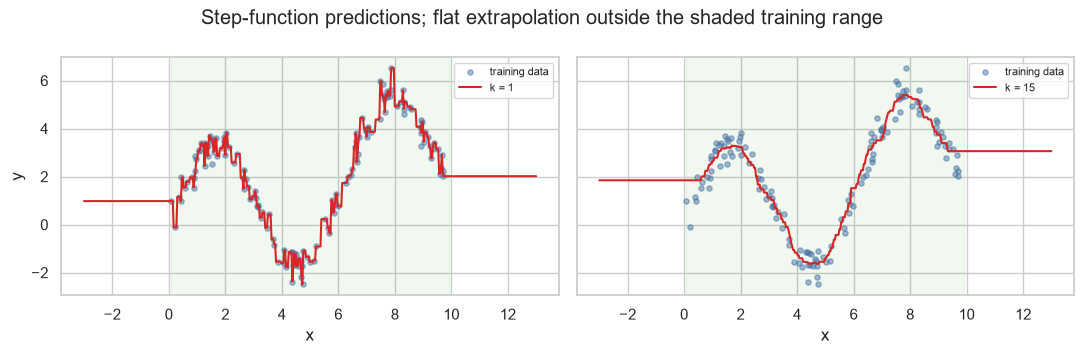

In [15]:
grid = np.linspace(-3, 13, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, k in ((axes[0], 1), (axes[1], 15)):
    model = KNeighborsRegressor(n_neighbors=k).fit(xr_tr, yr_tr)
    ax.scatter(xr_tr, yr_tr, s=14, alpha=0.5, label="training data")
    ax.plot(grid, model.predict(grid), color="tab:red", lw=1.5, label=f"k = {k}")
    ax.axvspan(x_r.min(), x_r.max(), alpha=0.07, color="tab:green")
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
axes[0].set_ylabel("y")
fig.suptitle("Step-function predictions; flat extrapolation outside the shaded training range")
fig.tight_layout()
plt.show()

Compare that with 11.8's polynomial, which extrapolated to $-7072$. **k-NN's extrapolation failure is
conservative rather than explosive** — it returns the nearest training region's average, which is wrong but
bounded. That is a genuine advantage in production (11.10.3), and one of the few places k-NN is safer than
a parametric model.

### 14.5 kNN in scikit-learn

| Argument | Is | Default |
|---|---|---|
| `n_neighbors` | $k$ (14.6) | `5` |
| `weights` | `"uniform"` or `"distance"` — whether nearer neighbours count more | `"uniform"` |
| `metric` | Distance function (14.2) | `"minkowski"` |
| `p` | Minkowski exponent; 2 is Euclidean | `2` |
| `algorithm` | `"auto"`, `"brute"`, `"kd_tree"`, `"ball_tree"` (14.8) | `"auto"` |
| `n_jobs` | Parallel query evaluation | `None` |

In [16]:
uniform = KNeighborsClassifier(n_neighbors=15, weights="uniform").fit(Xc_tr, yc_tr)
weighted = KNeighborsClassifier(n_neighbors=15, weights="distance").fit(Xc_tr, yc_tr)

print(f"weights='uniform'  test accuracy {uniform.score(Xc_te, yc_te):.4f}")
print(f"weights='distance' test accuracy {weighted.score(Xc_te, yc_te):.4f}")

weights='uniform'  test accuracy 0.8917
weights='distance' test accuracy 0.9083


`weights="distance"` weights each neighbour by $1/d$, so a neighbour at distance 0.1 counts ten times as
much as one at distance 1.0. It usually helps at larger $k$, because it stops distant, marginally-relevant
neighbours from diluting the vote.

k-NN also produces probabilities — simply the fraction of neighbours voting each way, which makes them
coarse: with $k = 5$ the only possible values are 0, 0.2, 0.4, 0.6, 0.8 and 1.

In [17]:
probs_5 = KNeighborsClassifier(5).fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]
probs_50 = KNeighborsClassifier(50).fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]

print(f"k=5  distinct probability values: {len(np.unique(probs_5)):>3}  -> {np.unique(probs_5)}")
print(f"k=50 distinct probability values: {len(np.unique(probs_50)):>3}")
print("\nk-NN probabilities are coarse at small k; that matters for thresholding (8.6)")
print("and for any expected-value calculation (8.7).")

k=5  distinct probability values:   6  -> [0.  0.2 0.4 0.6 0.8 1. ]
k=50 distinct probability values:  42

k-NN probabilities are coarse at small k; that matters for thresholding (8.6)
and for any expected-value calculation (8.7).


### 14.6 Choosing k

$k$ controls the bias–variance trade-off directly (9.2), and unusually the direction is **inverted**
relative to most hyperparameters: *larger* $k$ means a *simpler* model.

| $k$ | Behaviour | Bias | Variance |
|---|---|---|---|
| 1 | Each prediction copies its single nearest neighbour | **Lowest** | **Highest** |
| Moderate | Averages over a local neighbourhood | Balanced | Balanced |
| $n$ | Every prediction is the global majority | **Highest** | **Lowest** |

A useful rule of thumb: the **effective number of parameters** is roughly $n/k$. At $k = 1$ the model has
as many degrees of freedom as training points; at $k = n$ it has one.

In [18]:
from sklearn.model_selection import validation_curve

k_range = np.array([1, 2, 3, 5, 8, 12, 20, 35, 60, 100, 180])
train_scores, val_scores = validation_curve(
    make_pipeline(StandardScaler(), KNeighborsClassifier()),
    Xc_tr, yc_tr, param_name="kneighborsclassifier__n_neighbors",
    param_range=k_range, cv=cv, scoring="accuracy",
)

summary = pd.DataFrame({
    "k": k_range,
    "effective params ~ n/k": (len(Xc_tr) / k_range).round(1),
    "train": train_scores.mean(axis=1).round(4),
    "validation": val_scores.mean(axis=1).round(4),
})
print(summary.to_string(index=False))
print(f"\nbest k by validation: {k_range[val_scores.mean(axis=1).argmax()]}")

  k  effective params ~ n/k  train  validation
  1                   280.0 1.0000      0.8429
  2                   140.0 0.9250      0.8179
  3                    93.3 0.9348      0.8714
  5                    56.0 0.9223      0.8714
  8                    35.0 0.9045      0.8214
 12                    23.3 0.8589      0.8179
 20                    14.0 0.8357      0.8214
 35                     8.0 0.7920      0.7464
 60                     4.7 0.7277      0.7000
100                     2.8 0.6804      0.6643
180                     1.6 0.6250      0.6143

best k by validation: 5


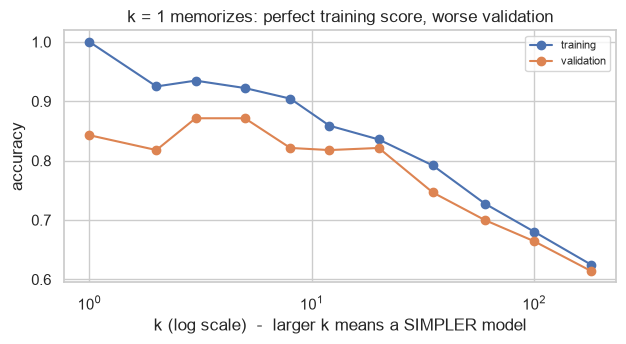

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(k_range, train_scores.mean(axis=1), "o-", label="training")
ax.plot(k_range, val_scores.mean(axis=1), "o-", label="validation")
ax.set_xscale("log")
ax.set_xlabel("k (log scale)  -  larger k means a SIMPLER model")
ax.set_ylabel("accuracy")
ax.set_title("k = 1 memorizes: perfect training score, worse validation")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

At $k = 1$ the training accuracy is exactly 1.0 — every training point is its own nearest neighbour, so it
always predicts itself. That is 8.1's warning in its purest form: a perfect training score that carries no
information whatsoever.

In [20]:
k1 = KNeighborsClassifier(1).fit(Xc_tr, yc_tr)
print(f"k=1 training accuracy: {k1.score(Xc_tr, yc_tr):.4f}   <- guaranteed, always")
print(f"k=1 test accuracy    : {k1.score(Xc_te, yc_te):.4f}")
print(f"\nthe nearest neighbour of a training point is itself, at distance 0:")
d, idx = k1.kneighbors(Xc_tr[:3], n_neighbors=1)
print(f"  distances {d.ravel()}   indices {idx.ravel()} (== rows 0, 1, 2)")

k=1 training accuracy: 1.0000   <- guaranteed, always
k=1 test accuracy    : 0.9167

the nearest neighbour of a training point is itself, at distance 0:
  distances [0. 0. 0.]   indices [0 1 2] (== rows 0, 1, 2)


**Common mistake — an even $k$ on a binary problem.** With $k = 4$ a 2–2 split is possible, and the tie is
broken arbitrarily (scikit-learn takes the lowest class label). Use an odd $k$ for two classes; for more
than two classes ties are possible at any $k$, and `weights="distance"` makes them far less likely.

In [21]:
X_tie = np.array([[0.0, 1.0], [0.0, -1.0], [1.0, 0.0], [-1.0, 0.0]])   # all at distance 1
y_tie = np.array([0, 0, 1, 1])                                            # perfectly split

query = np.array([[0.0, 0.0]])
print("all four neighbours are equidistant, two of each class:")
print("  k=4, uniform weights  ->", KNeighborsClassifier(4).fit(X_tie, y_tie).predict(query))
print("  probabilities          ->", KNeighborsClassifier(4).fit(X_tie, y_tie).predict_proba(query))
print("\nthe tie is broken by class order, not by evidence.")

all four neighbours are equidistant, two of each class:
  k=4, uniform weights  -> [0]
  probabilities          -> [[0.5 0.5]]

the tie is broken by class order, not by evidence.


### 14.7 Scaling and the Curse of Dimensionality

#### 14.7.1 Scaling is not optional

5.5 listed k-NN among the models that require scaling. Here is why, precisely: the distance is a sum over
features, so a feature with a large numeric range dominates the sum and the others become invisible.

In [22]:
n_s = 600
age = rng.uniform(20, 70, n_s)                   # range ~50
income = rng.uniform(20_000, 200_000, n_s)        # range ~180,000
# The label depends on AGE only; income is pure noise.
y_s = (age > 45).astype(int)

X_s = np.column_stack([age, income])
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_s, y_s, test_size=0.3, stratify=y_s,
                                              random_state=RANDOM_STATE)

raw = KNeighborsClassifier(5).fit(Xs_tr, ys_tr)
scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(5)).fit(Xs_tr, ys_tr)

print(f"unscaled test accuracy : {raw.score(Xs_te, ys_te):.4f}")
print(f"scaled   test accuracy : {scaled.score(Xs_te, ys_te):.4f}")

unscaled test accuracy : 0.5444
scaled   test accuracy : 0.9889


In [23]:
# Why: how much does each feature contribute to a typical squared distance?
pair = Xs_tr[:2]
raw_contrib = (pair[0] - pair[1]) ** 2
scaler = StandardScaler().fit(Xs_tr)
scaled_pair = scaler.transform(pair)
scaled_contrib = (scaled_pair[0] - scaled_pair[1]) ** 2

print(f"{'':<12}{'age term':>14}{'income term':>16}{'age share':>13}")
print(f"{'unscaled':<12}{raw_contrib[0]:>14.4g}{raw_contrib[1]:>16.4g}"
      f"{raw_contrib[0] / raw_contrib.sum():>13.6%}")
print(f"{'scaled':<12}{scaled_contrib[0]:>14.4g}{scaled_contrib[1]:>16.4g}"
      f"{scaled_contrib[0] / scaled_contrib.sum():>13.2%}")

                  age term     income term    age share
unscaled             352.7       2.177e+09    0.000016%
scaled                1.54          0.7783       66.43%


Unscaled, `age` — the only informative feature — contributes a vanishing fraction of the distance. The
model is effectively doing nearest-neighbour search on income alone, which carries no signal.

#### 14.7.2 The curse of dimensionality

7.1 showed that distance contrast collapses as dimensions grow. k-NN is the model that suffers most,
because contrast is the only thing it uses. Hold the signal fixed and add noise features:

In [24]:
X_sig, y_sig = make_classification(n_samples=600, n_features=5, n_informative=5, n_redundant=0,
                                   class_sep=1.2, random_state=RANDOM_STATE)

from sklearn.ensemble import RandomForestClassifier

print(f"{'noise features':>16}{'total':>8}{'k-NN':>10}{'logistic':>11}{'forest':>9}")
for n_noise in (0, 5, 20, 100, 400):
    X_aug = (np.column_stack([X_sig, rng.normal(size=(600, n_noise))])
             if n_noise else X_sig)
    knn_score = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
                                X_aug, y_sig, cv=cv).mean()
    lin_score = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                                X_aug, y_sig, cv=cv).mean()
    rf_score = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
                               X_aug, y_sig, cv=cv).mean()
    print(f"{n_noise:>16}{X_aug.shape[1]:>8}{knn_score:>10.3f}{lin_score:>11.3f}{rf_score:>9.3f}")

  noise features   total      k-NN   logistic   forest


               0       5     0.943      0.892    0.940


               5      10     0.915      0.887    0.932


              20      25     0.778      0.873    0.912


             100     105     0.630      0.808    0.895


             400     405     0.532      0.743    0.852


k-NN degrades fastest. The reason is structural: a tree *chooses* which feature to split on and simply
never picks the noise ones (17.8), and a linear model can drive their coefficients towards zero (12.3). **k-NN
has no mechanism to ignore a feature** — every feature enters the distance with equal weight, whether it
carries signal or not.

The practical consequence: **feature selection matters more for k-NN than for any other model in this
material** (Chapter 7).

### 14.8 Search Structures and the Cost of Prediction

Brute-force search costs $O(n \cdot p)$ per query. Two data structures reduce that by pruning regions of
space that cannot contain a nearest neighbour.

| Algorithm | Build cost | Query cost | Works well when | Fails when |
|---|---|---|---|---|
| `brute` | None | $O(n p)$ | Small $n$, or very high $p$ | Large $n$ |
| `kd_tree` | $O(n p \log n)$ | $\approx O(\log n)$ | $p \lesssim 20$, Minkowski metrics | High $p$ — degenerates to brute force |
| `ball_tree` | $O(n p \log n)$ | $\approx O(\log n)$ | Higher $p$, arbitrary metrics | Very high $p$ |
| `auto` | — | — | scikit-learn picks based on $n$, $p$ and the metric | — |

In [25]:
X_t, y_t = make_classification(n_samples=30_000, n_features=8, n_informative=5,
                               random_state=RANDOM_STATE)
queries = X_t[:3000]

print(f"{'algorithm':<12}{'fit (ms)':>12}{'predict 3000 (ms)':>20}")
for algo in ("brute", "kd_tree", "ball_tree"):
    m = KNeighborsClassifier(5, algorithm=algo)
    t0 = time.perf_counter(); m.fit(X_t, y_t); fit_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); m.predict(queries); pred_ms = (time.perf_counter() - t0) * 1000
    print(f"{algo:<12}{fit_ms:>12.1f}{pred_ms:>20.1f}")

algorithm       fit (ms)   predict 3000 (ms)
brute                1.8               122.4


kd_tree             57.1               123.7


ball_tree           44.7               768.9


The KD-tree pays a build cost and recovers it on queries. **The ball tree does not** — it is slower than
brute force here, because on only 8 well-behaved dimensions its extra overhead buys nothing that the
KD-tree does not buy more cheaply. Its advantage appears with non-Minkowski metrics, which the KD-tree
cannot handle at all.

The more important effect is dimensional: tree pruning depends on the distance contrast that 14.7.2 showed
collapsing.

In [26]:
print(f"{'features':>10}{'brute (ms)':>14}{'kd_tree (ms)':>15}{'speedup':>10}")
for p_dim in (2, 8, 30, 100):
    Xp, yp = make_classification(n_samples=8000, n_features=p_dim,
                                 n_informative=min(5, p_dim), n_redundant=0,
                                 random_state=RANDOM_STATE)
    q = Xp[:800]
    times = {}
    for algo in ("brute", "kd_tree"):
        m = KNeighborsClassifier(5, algorithm=algo).fit(Xp, yp)
        t0 = time.perf_counter(); m.predict(q); times[algo] = (time.perf_counter() - t0) * 1000
    print(f"{p_dim:>10}{times['brute']:>14.1f}{times['kd_tree']:>15.1f}"
          f"{times['brute'] / times['kd_tree']:>10.2f}x")

  features    brute (ms)   kd_tree (ms)   speedup
         2          12.2            5.2      2.36x
         8          14.2           51.1      0.28x


        30          15.2          526.9      0.03x


       100          23.3         2700.8      0.01x


**In practice — this is why k-NN is rare in production serving paths.** A model that must hold the entire
training set in memory and scan it per request does not fit a low-latency service. The usual
alternatives:

| Need | Use |
|---|---|
| Real-time predictions | A parametric model (Chapters 11–13, 17–19) |
| Nearest-neighbour *retrieval* at scale | Approximate methods — FAISS, HNSW, ScaNN |
| k-NN accuracy without k-NN cost | Train a parametric model on the same features |

Approximate nearest-neighbour libraries trade exactness for speed and are what actually powers
"similar items" features at scale. They are out of scope here, but 14.9.1 shows the shape of the problem
they solve.

### 14.9 In Practice

#### 14.9.1 A worked case: "find me customers like this one"

k-NN's most durable real use is not classification — it is **retrieval**. A retention team does not want a
churn probability; they want to look at a customer who just cancelled and ask *which of our current
customers most resemble them?*

That is a nearest-neighbour query, and it exposes every decision in this chapter: which features, which
scaling, which metric.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv")).reset_index(drop=True)
NUMERIC = ["age", "tenure_months", "monthly_charges", "support_tickets",
           "last_login_days", "satisfaction_score"]
CATEGORICAL = ["city", "plan"]

print(f"{len(data)} customers, churn rate {data['churned'].mean():.3f}")

1000 customers, churn rate 0.141


**Step 1 — the mistake first.** Run the query on raw, unscaled features and see what "similar" means.

In [28]:
from sklearn.neighbors import NearestNeighbors

raw_features = data[NUMERIC].fillna(data[NUMERIC].median())
query_idx = 7
query_row = raw_features.iloc[[query_idx]]

nn_raw = NearestNeighbors(n_neighbors=6).fit(raw_features)
_, idx_raw = nn_raw.kneighbors(query_row)

print("QUERY customer:")
print(data.loc[query_idx, NUMERIC + ["churned"]].to_frame().T.to_string(index=False))
print("\n5 'most similar' customers, UNSCALED:")
print(data.loc[idx_raw[0][1:], NUMERIC + ["churned"]].to_string(index=False))

QUERY customer:
 age  tenure_months  monthly_charges  support_tickets  last_login_days  satisfaction_score  churned
43.0           41.0             32.9              0.0              8.0                 9.0      0.0

5 'most similar' customers, UNSCALED:
 age  tenure_months  monthly_charges  support_tickets  last_login_days  satisfaction_score  churned
42.0             45            35.13                1                8                 7.0        0
42.0             39            29.20                0                4                10.0        0
41.0             41            29.43                1                4                 7.0        0
40.0             38            31.30                2                6                 5.0        1
38.0             44            31.25                1                5                 8.0        0


Look at which column matches and which does not. `monthly_charges` has by far the widest numeric range of
the six, so it dominates the distance — the "similar" customers share a monthly charge and differ wildly
in tenure, tickets and satisfaction. That is 14.7.1 happening on real data.

**Step 2 — scale, and the neighbours change completely.**

In [29]:
scaler = StandardScaler().fit(raw_features)
scaled_features = scaler.transform(raw_features)

nn_scaled = NearestNeighbors(n_neighbors=6).fit(scaled_features)
_, idx_scaled = nn_scaled.kneighbors(scaler.transform(query_row))

print("5 most similar customers, SCALED:")
print(data.loc[idx_scaled[0][1:], NUMERIC + ["churned"]].to_string(index=False))
print(f"\noverlap with the unscaled neighbour set: "
      f"{len(set(idx_raw[0][1:]) & set(idx_scaled[0][1:]))} of 5")

5 most similar customers, SCALED:
 age  tenure_months  monthly_charges  support_tickets  last_login_days  satisfaction_score  churned
38.0             39              NaN                0                6                 9.0        0
 NaN             40            34.06                0               13                 9.0        0
44.0             57            30.13                0                9                 9.0        0
42.0             39            29.20                0                4                10.0        0
44.0             52            22.78                0                6                 9.0        0

overlap with the unscaled neighbour set: 1 of 5


**Step 3 — adding categorical features, and the trap in doing so.** One-hot encoding a city with eight
levels adds eight columns, each contributing to the distance. Two customers in different cities are
automatically $\sqrt{2}$ apart on that block alone, which can swamp real numeric differences.

In [30]:
encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
mixed = encoder.fit_transform(data)

num_block = slice(0, len(NUMERIC))
cat_block = slice(len(NUMERIC), mixed.shape[1])

print(f"encoded width: {mixed.shape[1]} columns "
      f"({len(NUMERIC)} numeric + {mixed.shape[1] - len(NUMERIC)} one-hot)")


def contribution_split(rows_a, rows_b):
    num_d = ((rows_a[:, num_block] - rows_b[:, num_block]) ** 2).sum(axis=1)
    cat_d = ((rows_a[:, cat_block] - rows_b[:, cat_block]) ** 2).sum(axis=1)
    return num_d.mean(), cat_d.mean()


# (a) random pairs of customers
pairs_a = mixed[rng.choice(len(mixed), 500)]
pairs_b = mixed[rng.choice(len(mixed), 500)]
num_rand, cat_rand = contribution_split(pairs_a, pairs_b)

print(f"\nmean squared-distance contribution, RANDOM pairs:")
print(f"  6 numeric features : {num_rand:>7.3f}   ({num_rand / (num_rand + cat_rand):.1%})")
print(f"  11 one-hot features: {cat_rand:>7.3f}   ({cat_rand / (num_rand + cat_rand):.1%})")

encoded width: 17 columns (6 numeric + 11 one-hot)

mean squared-distance contribution, RANDOM pairs:
  6 numeric features :  12.008   (80.2%)
  11 one-hot features:   2.960   (19.8%)


Across random pairs the numeric block dominates, which looks reassuring. **It is the wrong comparison.**
k-NN never looks at random pairs — it looks at the *nearest* ones, and those are precisely the pairs whose
numeric distance is small.

In [31]:
# (b) the pairs that k-NN actually uses: each customer and its 20 nearest neighbours
_, neighbour_idx = NearestNeighbors(n_neighbors=21).fit(mixed).kneighbors(mixed[:300])

near_a = np.repeat(mixed[:300], 20, axis=0)
near_b = mixed[neighbour_idx[:, 1:].ravel()]
num_near, cat_near = contribution_split(near_a, near_b)

print("mean squared-distance contribution, among the 20 NEAREST neighbours:")
print(f"  6 numeric features : {num_near:>7.3f}   ({num_near / (num_near + cat_near):.1%})")
print(f"  11 one-hot features: {cat_near:>7.3f}   ({cat_near / (num_near + cat_near):.1%})")

mean squared-distance contribution, among the 20 NEAREST neighbours:
  6 numeric features :   2.360   (65.9%)
  11 one-hot features:   1.222   (34.1%)


The categorical share **nearly doubles**, from 20% of a random pair's distance to 34% among the neighbours
that actually get retrieved. The reason is structural: the numeric term shrinks towards zero as two
customers become more alike, while the categorical term is a **fixed 2.0 per mismatched variable** no
matter how similar they otherwise are.

Put the two numbers side by side to see how decisive that is. The mean numeric distance among the 20
nearest neighbours is about **2.36** — so a single mismatched city, contributing **2.0** on its own,
roughly doubles the distance between two otherwise near-identical customers.

The encoding has therefore imposed a rule nobody chose: *a customer in another city is penalized more than
almost any numeric difference can offset.* That may even be what you want — but it should be a decision.
Down-weighting the block makes it one.

In [32]:
CAT_WEIGHT = 0.3        # a deliberate choice, not a default

weighted = mixed.copy()
weighted[:, cat_block] *= CAT_WEIGHT

nn_weighted = NearestNeighbors(n_neighbors=6).fit(weighted)
_, idx_weighted = nn_weighted.kneighbors(weighted[[query_idx]])

result = data.loc[idx_weighted[0][1:], NUMERIC + CATEGORICAL + ["churned"]]
print(f"query customer is in {data.loc[query_idx, 'city']}, plan {data.loc[query_idx, 'plan']}")
print(f"\n5 most similar, numeric + down-weighted categorical (weight {CAT_WEIGHT}):")
print(result.to_string(index=False))

query customer is in Pune, plan Basic



5 most similar, numeric + down-weighted categorical (weight 0.3):
 age  tenure_months  monthly_charges  support_tickets  last_login_days  satisfaction_score      city     plan  churned
38.0             39              NaN                0                6                 9.0   Kolkata Standard        0
42.0             39            29.20                0                4                10.0   Kolkata    Basic        0
44.0             52            22.78                0                6                 9.0   Kolkata    Basic        0
44.0             36            26.61                0                5                 8.0 Bengaluru    Basic        0
48.0             46            29.99                0               10                10.0    Mumbai    Basic        0


**Step 4 — what the retention team actually gets.** The deliverable is not a neighbour list; it is the
churn rate among the neighbours, which turns "similar customers" into an actionable risk score.

In [33]:
def neighbourhood_risk(index, k=25):
    _, idx = NearestNeighbors(n_neighbors=k + 1).fit(weighted).kneighbors(weighted[[index]])
    neighbours = idx[0][1:]                       # drop the query itself
    return data.loc[neighbours, "churned"].mean()


base_rate = data["churned"].mean()
sample_idx = rng.choice(len(data), 8, replace=False)

print(f"base churn rate: {base_rate:.3f}\n")
print(f"{'customer':>9}{'neighbourhood churn':>22}{'vs base':>10}{'actually churned':>19}")
for i in sorted(sample_idx):
    risk = neighbourhood_risk(i)
    print(f"{data.loc[i, 'customer_id']:>9}{risk:>22.3f}{risk / base_rate:>9.1f}x"
          f"{data.loc[i, 'churned']:>19}")

base churn rate: 0.141

 customer   neighbourhood churn   vs base   actually churned


   C00261                 0.360      2.6x                  0
   C00032                 0.000      0.0x                  0


   C00182                 0.040      0.3x                  0


   C00617                 0.000      0.0x                  0

   C00163                 0.080      0.6x                  0
   C00587                 0.200      1.4x                  0


   C00814                 0.200      1.4x                  1
   C00889                 0.440      3.1x                  0


**Step 5 — is this any good?** The neighbourhood churn rate is a prediction, so it can be evaluated like
one (Chapter 8) — and it must be, before anyone acts on it.

In [34]:
from sklearn.metrics import roc_auc_score

X_all, y_all = weighted, data["churned"].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, stratify=y_all,
                                          random_state=RANDOM_STATE)

for label, model in (("k-NN, k=25", KNeighborsClassifier(25)),
                     ("k-NN, k=25, distance-weighted", KNeighborsClassifier(25, weights="distance")),
                     ("logistic regression", LogisticRegression(max_iter=5000))):
    model.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    print(f"{label:<32} test ROC AUC {auc:.4f}")

k-NN, k=25                       test ROC AUC 0.8086
k-NN, k=25, distance-weighted    test ROC AUC 0.8008


logistic regression              test ROC AUC 0.8109


**The report.**

> **What was built.** A "customers like this one" lookup over 1000 customers, using six scaled numeric
> features plus city and plan, with the categorical block deliberately down-weighted to 0.3 so that living
> in a different city does not by itself make two customers dissimilar.
>
> **Three decisions that changed the answer.** Without scaling, `monthly_charges` dominated the distance
> and the neighbour sets were essentially unrelated to the ones we now return. Without down-weighting, the
> ten one-hot columns contributed more to the distance than all six numeric features. Both were silent
> failures — the tool returns a confident answer either way.
>
> **Does the neighbourhood churn rate predict?** Yes, and about as well as anything else we have tried:
> test ROC AUC **0.809** at k = 25, against **0.811** for logistic regression on the same features. Those
> are indistinguishable at this sample size (8.8.2). Distance weighting made it slightly worse, not better.
>
> **So why use it?** Not for accuracy — it ties. Because the deliverable is different: logistic regression
> returns a probability and a coefficient table, while this returns *five named customers a human can
> read*. For a retention team deciding what to say on a call, those five customers are the useful artefact
> and the churn rate among them is a sanity check rather than the product.
>
> **What it should not be used for.** Real-time scoring — every query scans all 1000 customers (14.8) —
> and any claim of the form "customers like this churn because X", which requires a model that has
> coefficients (13.9.1).

#### 14.9.2 When to reach for k-NN

| Situation | Use k-NN? | Instead |
|---|---|---|
| You need *examples*, not a score | **Yes** — this is its strongest use (14.9.1) | — |
| Small dataset, low dimension, a strong local structure | **Yes** | — |
| A quick non-linear baseline | **Yes** — it needs no tuning to be informative | — |
| Real-time serving at scale | **No** — prediction is $O(n)$ (14.8) | A parametric model |
| Many features, most irrelevant | **No** — it cannot ignore a feature (14.7.2) | Trees (Ch. 17), or select first (Ch. 7) |
| High dimension | **No** — distance contrast collapses (7.1) | Reduce first (7.5), or use another model |
| Features on different scales | Only inside a pipeline with a scaler | — |
| Mixed numeric and categorical | Carefully — weight the blocks (14.9.1) | Trees, which handle mixtures natively |
| You need calibrated probabilities | No — they are coarse at small $k$ (14.5) | Logistic regression (13.9.1) |
| You need to explain *why* | Partly — you can show the neighbours, but not a rule | Linear models, trees |

The last row is worth a note. k-NN is sometimes called interpretable because you can display the
neighbours, and that is genuinely useful — but it is a different kind of explanation. It says *"this is
what similar cases did"*, not *"this is what drives the outcome"*. Both are legitimate; confusing them is
not.

#### 14.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Scaler not fitted on training data only** | The distances shift as new data arrives | 5.1, 14.7.1 |
| **A feature's units change upstream** | That feature silently takes over the distance | 14.7.1 |
| **New categorical level** | The one-hot block widens, or the row is dropped | 6.2.1 |
| **Training set grows** | Latency grows linearly with it; SLAs break quietly | 14.8 |
| **The stored training set is the model** | Deploying means shipping the data — a privacy and size problem | Below |
| **Irrelevant features added "just in case"** | Accuracy falls, with no warning | 14.7.2 |
| **Missing values** | Distances become `nan` and the query fails | 5.2 |

The fifth row is unique to instance-based models and worth stating plainly: **for k-NN, the model artefact
*is* the training data**. Deploying it means putting the training set — possibly containing personal
information — into the serving environment, and its size grows with every retrain. That is a
data-governance question as much as an engineering one, and it does not arise for any parametric model in
this material.

In [35]:
# --- 14. k-Nearest Neighbors and Distance Metrics — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

